# Graded Response Model — PROMIS Sleep-Wake (Single Scale)

Fits a single-dimensional GRM to 120 PROMIS Sleep-Wake calibration items.
Data from Harvard Dataverse (doi:10.7910/DVN/XESLRZ).

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['TQDM_DISABLE'] = '1'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from plot_helpers import (plot_loss_comparison, plot_forest_discriminations,
                          plot_ability_scatter, plot_ability_distributions,
                          plot_thresholds, plot_individual_abilities,
                          plot_imputation_weights_pcolormesh)

## 1. Load Data

In [2]:
from bayesianquilts.data.promis_sleep import get_data, item_keys, response_cardinality

df, num_people = get_data(reorient=True, polars_out=True)
print(f"Dataset: {num_people} people, {len(item_keys)} items, {response_cardinality} response categories (0-{response_cardinality - 1})")
print(f"Item keys: {item_keys[:10]}... ({len(item_keys)} total)")
df.head()

Dataset: 2252 people, 126 items, 5 response categories (0-4)
Item keys: ['Sleep1', 'Sleep2', 'Sleep3', 'Sleep4', 'Sleep5', 'Sleep6', 'Sleep7', 'Sleep8', 'Sleep9', 'Sleep10']... (126 total)


person,Sleep1,Sleep2,Sleep3,Sleep4,Sleep5,Sleep6,Sleep7,Sleep8,Sleep9,Sleep10,Sleep11,Sleep12,Sleep13,Sleep14,Sleep15,Sleep16,Sleep17,Sleep18,Sleep19,Sleep20,Sleep21,Sleep22,Sleep23,Sleep24,Sleep25,Sleep26,Sleep27,Sleep28,Sleep29,Sleep30,Sleep31,Sleep32,Sleep33,Sleep34,Sleep35,Sleep36,…,Sleep92,Sleep93,Sleep94,Sleep95,Sleep96,Sleep97,Sleep98,Sleep99,Sleep100,Sleep101,Sleep102,Sleep103,Sleep104,Sleep105,Sleep106,Sleep107,Sleep108,Sleep109,Sleep110,Sleep111,Sleep112,Sleep113,Sleep114,Sleep115,Sleep116,Sleep117,Sleep118,Sleep119,Sleep120,Sleep121,Sleep122,Sleep123,Sleep124,Sleep125,Sleep126,Sleep127,Sleep128
u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,…,3.0,3.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,3.0,2.0,0.0,0.0,1.0,3.0,1.0,0.0,2.0,1.0,3.0,1.0,0.0,1.0,1.0,0.0,0.0,4.0,2.0,1.0,2.0,0.0,0.0,4.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,1.0,2.0,3.0,3.0,2.0,0.0,1.0,3.0,2.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,3.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,3.0,3.0,3.0,2.0,2.0,1.0,2.0,1.0,-1.0,…,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,2.0,1.0,3.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,0.0,0.0,3.0,2.0,0.0,2.0,1.0
2,2.0,2.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,3.0,3.0,2.0,4.0,0.0,0.0,3.0,4.0,2.0,1.0,1.0,0.0,2.0,1.0,2.0,1.0,0.0,0.0,2.0,-1.0,…,3.0,1.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,2.0,1.0,3.0,2.0,0.0,1.0,1.0,3.0,2.0,1.0,1.0,1.0,0.0,1.0,4.0,3.0,2.0,3.0,0.0,0.0,2.0,3.0,4.0,2.0,0.0
3,0.0,1.0,0.0,2.0,2.0,3.0,1.0,1.0,1.0,1.0,2.0,1.0,0.0,1.0,1.0,0.0,2.0,2.0,1.0,0.0,3.0,1.0,2.0,4.0,1.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,-1.0,…,0.0,0.0,3.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,4.0,3.0,1.0,1.0,0.0,3.0,2.0,3.0,1.0,4.0,2.0,2.0,2.0,1.0,0.0,1.0,2.0,2.0,4.0,1.0,3.0,0.0,1.0,1.0,2.0
4,0.0,0.0,1.0,2.0,0.0,2.0,1.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,2.0,4.0,2.0,0.0,0.0,1.0,0.0,2.0,1.0,1.0,3.0,2.0,2.0,0.0,1.0,1.0,-1.0,…,3.0,4.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,4.0,1.0,1.0,0.0,1.0,1.0,1.0,4.0,3.0,2.0,1.0,0.0,0.0,1.0,2.0,2.0,0.0,0.0


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 2252


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 13188
N: 2252, Batch size: 256, Steps per epoch: 9


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    lr_decay_factor=0.975,
    patience=10,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Final baseline loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/9 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/9 [00:03<?, ?batch/s, best_loss=inf, loss=248.2345]

Epoch 1/200 (LR: 0.000200):  11%|█         | 1/9 [00:03<00:31,  3.96s/batch, best_loss=inf, loss=248.2345]

Epoch 1/200 (LR: 0.000200):  11%|█         | 1/9 [00:04<00:31,  3.96s/batch, best_loss=inf, loss=247.2263]

...

Epoch 21/200 (LR: 0.000144):  56%|█████▌    | 5/9 [00:04<00:02,  1.96batch/s, best_loss=237.5718, loss=244.4275]

Epoch 21/200 (LR: 0.000144):  56%|█████▌    | 5/9 [00:04<00:02,  1.96batch/s, best_loss=237.5718, loss=246.0116]

Epoch 21/200 (LR: 0.000144):  56%|█████▌    | 5/9 [00:06<00:02,  1.96batch/s, best_loss=237.5718, loss=196.7853]

Epoch 21/200 (LR: 0.000144): 100%|██████████| 9/9 [00:06<00:00,  1.74batch/s, best_loss=237.5718, loss=196.7853]

  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000140

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---
Final baseline loss: 239.30


In [6]:
model_baseline.save_to_disk('grm_baseline')

In [7]:
def calibrate_manually(model, n_samples=32, seed=42):
    try:
        surrogate = model.surrogate_distribution_generator(model.params)
        key = jax.random.PRNGKey(seed)
        samples = surrogate.sample(n_samples, seed=key)
        expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
        model.calibrated_expectations = expectations
        model.surrogate_sample = samples
    except KeyError as e:
        print(f"  Warning: surrogate sampling failed ({e}), using point estimates")
        point_estimates = {}
        for key_name, value in model.params.items():
            parts = key_name.split('\\')
            if len(parts) >= 4:
                param_name = parts[0]
                if parts[-2] == 'normal' and parts[-1] == 'loc':
                    point_estimates[param_name] = value
        model.calibrated_expectations = point_estimates

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 4. Fit Pairwise Ordinal Stacking Model

In [8]:
from bayesianquilts.imputation.pairwise_stacking import PairwiseOrdinalStackingModel

# Convert to pandas, replacing -1 (missing marker) with NaN
pandas_df = sub_df.select(item_keys).to_pandas()
pandas_df = pandas_df.replace(-1, np.nan)
print(f"Missing values per item:\n{pandas_df.isna().sum()}")

pairwise_model = PairwiseOrdinalStackingModel(
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

pairwise_model.fit(
    pandas_df,
    n_top_features=12,
    n_jobs=-1,
    seed=42,
)

Missing values per item:
Sleep1      7
Sleep2      0
Sleep3      0
Sleep4      1
Sleep5      0
           ..
Sleep124    1
Sleep125    2
Sleep126    1
Sleep127    3
Sleep128    1
Length: 126, dtype: int64
Computing feature correlations...


Fitting PairwiseOrdinalStackingModel
  Variables: 126
  Observations: 2252
  Min obs per model: 5
  Parallel jobs: -1
  Top features per target: 12
  DM alpha prior: 0.5
  Global ordinal values: [0. 1. 2. 3. 4.] (n=5)

Fitting marginal regression models...
  126 of 126 remaining


  Var 0 (Sleep1): elpd/n=-0.3240


  Var 1 (Sleep2): elpd/n=-0.3524
  Var 2 (Sleep3): elpd/n=-0.2869


  Var 3 (Sleep4): elpd/n=-0.3230
  Var 4 (Sleep5): elpd/n=-0.2819
  Var 5 (Sleep6): elpd/n=-0.3212
  Var 6 (Sleep7): elpd/n=-0.2867
  Var 7 (Sleep8): elpd/n=-0.1549
  Var 8 (Sleep9): elpd/n=-0.1881
  Var 9 (Sleep10): elpd/n=-0.2695


...

  DM (Sleep115->Sleep127): elpd/n=-1.1001, n=2249
  DM (Sleep116->Sleep127): elpd/n=-1.1040, n=2249
  DM (Sleep117->Sleep127): elpd/n=-1.0980, n=2249
  DM (Sleep118->Sleep127): elpd/n=-1.1048, n=2249
  DM (Sleep119->Sleep127): elpd/n=-1.0887, n=2249
  DM (Sleep120->Sleep127): elpd/n=-1.0905, n=2249
  DM (Sleep121->Sleep127): elpd/n=-1.0904, n=2249
  DM (Sleep122->Sleep127): elpd/n=-1.1030, n=2249
  DM (Sleep123->Sleep127): elpd/n=-1.0705, n=2249
  DM (Sleep124->Sleep127): elpd/n=-1.0789, n=2249
  DM (Sleep125->Sleep127): elpd/n=-1.0929, n=2248
  DM (Sleep126->Sleep127): elpd/n=-1.0681, n=2249
  DM (Sleep128->Sleep127): elpd/n=-1.0928, n=2249
  DM (Sleep1->Sleep128): elpd/n=-1.4990, n=2244
  DM (Sleep2->Sleep128): elpd/n=-1.4485, n=2251
  DM (Sleep3->Sleep128): elpd/n=-1.5024, n=2251
  DM (Sleep4->Sleep128): elpd/n=-1.3832, n=2250
  DM (Sleep5->Sleep128): elpd/n=-1.4849, n=2251
  DM (Sleep6->Sleep128): elpd/n=-1.4078, n=2250
  DM (Sleep7->Sleep128): elpd/n=-1.4260, n=2251
  DM (Sleep8->

  DM (Sleep20->Sleep128): elpd/n=-1.3831, n=2251
  DM (Sleep21->Sleep128): elpd/n=-1.4796, n=2251
  DM (Sleep22->Sleep128): elpd/n=-1.4796, n=2251
  DM (Sleep23->Sleep128): elpd/n=-1.4905, n=2251
  DM (Sleep24->Sleep128): elpd/n=-1.4816, n=2196
  DM (Sleep25->Sleep128): elpd/n=-1.3503, n=2251
  DM (Sleep26->Sleep128): elpd/n=-1.3686, n=2251
  DM (Sleep27->Sleep128): elpd/n=-1.3500, n=2251
  DM (Sleep28->Sleep128): elpd/n=-1.3513, n=2249
  DM (Sleep29->Sleep128): elpd/n=-1.3675, n=2251
  DM (Sleep30->Sleep128): elpd/n=-1.3624, n=2251
  DM (Sleep31->Sleep128): elpd/n=-1.3487, n=2251
  DM (Sleep32->Sleep128): elpd/n=-1.3848, n=2251
  DM (Sleep33->Sleep128): elpd/n=-1.3952, n=2250
  DM (Sleep34->Sleep128): elpd/n=-1.4130, n=2251
  DM (Sleep35->Sleep128): elpd/n=-1.3982, n=2251
  DM (Sleep36->Sleep128): elpd/n=-1.3956, n=287
  DM (Sleep37->Sleep128): elpd/n=-1.3090, n=215
  DM (Sleep38->Sleep128): elpd/n=-1.4469, n=257
  DM (Sleep39->Sleep128): elpd/n=-1.4116, n=199
  DM (Sleep40->Sleep128)

  DM (Sleep52->Sleep128): elpd/n=-1.4906, n=2251
  DM (Sleep53->Sleep128): elpd/n=-1.4584, n=2249
  DM (Sleep54->Sleep128): elpd/n=-1.4374, n=2250
  DM (Sleep55->Sleep128): elpd/n=-1.4800, n=2250
  DM (Sleep56->Sleep128): elpd/n=-1.5039, n=2251
  DM (Sleep57->Sleep128): elpd/n=-1.5053, n=2248
  DM (Sleep58->Sleep128): elpd/n=-1.4765, n=2230
  DM (Sleep59->Sleep128): elpd/n=-1.4991, n=2250
  DM (Sleep60->Sleep128): elpd/n=-1.4988, n=2251
  DM (Sleep61->Sleep128): elpd/n=-1.5026, n=2229
  DM (Sleep62->Sleep128): elpd/n=-1.5020, n=2248
  DM (Sleep63->Sleep128): elpd/n=-1.4913, n=2251
  DM (Sleep64->Sleep128): elpd/n=-1.4976, n=2250
  DM (Sleep65->Sleep128): elpd/n=-1.4113, n=2251
  DM (Sleep66->Sleep128): elpd/n=-1.4329, n=2251
  DM (Sleep67->Sleep128): elpd/n=-1.4119, n=2251
  DM (Sleep68->Sleep128): elpd/n=-1.4144, n=2251
  DM (Sleep69->Sleep128): elpd/n=-1.4176, n=2251
  DM (Sleep70->Sleep128): elpd/n=-1.4415, n=2251
  DM (Sleep71->Sleep128): elpd/n=-1.4258, n=2251
  DM (Sleep72->Sleep

  DM (Sleep83->Sleep128): elpd/n=-1.4555, n=2249
  DM (Sleep84->Sleep128): elpd/n=-1.4902, n=2251
  DM (Sleep85->Sleep128): elpd/n=-1.5185, n=1395
  DM (Sleep86->Sleep128): elpd/n=-1.4330, n=2251
  DM (Sleep87->Sleep128): elpd/n=-1.4430, n=2251
  DM (Sleep88->Sleep128): elpd/n=-1.4941, n=2251
  DM (Sleep89->Sleep128): elpd/n=-1.4460, n=2245
  DM (Sleep90->Sleep128): elpd/n=-1.4006, n=2251
  DM (Sleep91->Sleep128): elpd/n=-1.4827, n=2251
  DM (Sleep92->Sleep128): elpd/n=-1.4521, n=2250
  DM (Sleep93->Sleep128): elpd/n=-1.4495, n=2250
  DM (Sleep94->Sleep128): elpd/n=-1.4698, n=2250
  DM (Sleep95->Sleep128): elpd/n=-1.4990, n=2233
  DM (Sleep96->Sleep128): elpd/n=-1.4984, n=2237
  DM (Sleep97->Sleep128): elpd/n=-1.5003, n=2249
  DM (Sleep98->Sleep128): elpd/n=-1.4902, n=2249
  DM (Sleep99->Sleep128): elpd/n=-1.5060, n=2242
  DM (Sleep100->Sleep128): elpd/n=-1.4899, n=2246
  DM (Sleep101->Sleep128): elpd/n=-1.4788, n=2251
  DM (Sleep102->Sleep128): elpd/n=-1.4963, n=2180


  DM (Sleep103->Sleep128): elpd/n=-1.4745, n=2251
  DM (Sleep104->Sleep128): elpd/n=-1.4895, n=2250
  DM (Sleep105->Sleep128): elpd/n=-1.3661, n=2251
  DM (Sleep106->Sleep128): elpd/n=-1.4703, n=2250
  DM (Sleep107->Sleep128): elpd/n=-1.4627, n=2251
  DM (Sleep108->Sleep128): elpd/n=-1.4161, n=2249
  DM (Sleep109->Sleep128): elpd/n=-1.3758, n=2251
  DM (Sleep110->Sleep128): elpd/n=-1.3692, n=2251
  DM (Sleep111->Sleep128): elpd/n=-1.3880, n=2251
  DM (Sleep112->Sleep128): elpd/n=-1.3700, n=2251
  DM (Sleep113->Sleep128): elpd/n=-1.4744, n=2250
  DM (Sleep114->Sleep128): elpd/n=-1.3606, n=2251
  DM (Sleep115->Sleep128): elpd/n=-1.3522, n=2251
  DM (Sleep116->Sleep128): elpd/n=-1.3405, n=2251
  DM (Sleep117->Sleep128): elpd/n=-1.3011, n=2251
  DM (Sleep118->Sleep128): elpd/n=-1.4875, n=2251
  DM (Sleep119->Sleep128): elpd/n=-1.2070, n=2251
  DM (Sleep120->Sleep128): elpd/n=-1.1982, n=2251
  DM (Sleep121->Sleep128): elpd/n=-1.1895, n=2251
  DM (Sleep122->Sleep128): elpd/n=-1.4944, n=2251


In [9]:
pairwise_model.save('pairwise_stacking_model.yaml')
pairwise_model.compute_optimal_stacking_weights()

Optimal stacking weights computed for 126 targets


## 4b. Fit Pairwise-Only GRM

Uses only the pairwise ordinal stacking ensemble (no IRT blending, w=1 for all items).

In [10]:
from bayesianquilts.imputation.mixed import PairwiseOnlyImputationModel

pairwise_imputation = PairwiseOnlyImputationModel(mice_model=pairwise_model)
print(pairwise_imputation.summary())

model_pairwise = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    imputation_model=pairwise_imputation,
    dtype=jnp.float64,
)

print("Warm-starting from baseline model parameters")

res_pairwise = model_pairwise.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    lr_decay_factor=0.975,
    patience=10,
    zero_nan_grads=True,
    initial_values=model_baseline.params,
)

losses_pairwise = res_pairwise[0]
print(f"Final pairwise loss: {losses_pairwise[-1]:.2f}")
model_pairwise.save_to_disk('grm_pairwise')

Pairwise-Only Imputation (w_mice = 1.0 for all items):
  Variables: 126
  Univariate models: 1512


Warm-starting from baseline model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/9 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/9 [00:05<?, ?batch/s, best_loss=inf, loss=255.2023]

Epoch 1/200 (LR: 0.000200):  11%|█         | 1/9 [00:05<00:40,  5.07s/batch, best_loss=inf, loss=255.2023]

...

Epoch 12/200 (LR: 0.000106):  44%|████▍     | 4/9 [00:15<00:15,  3.17s/batch, best_loss=243.9578, loss=254.1296]

Epoch 12/200 (LR: 0.000106):  56%|█████▌    | 5/9 [00:15<00:12,  3.12s/batch, best_loss=243.9578, loss=254.1296]

Epoch 12/200 (LR: 0.000106):  56%|█████▌    | 5/9 [00:18<00:12,  3.12s/batch, best_loss=243.9578, loss=255.8000]

Epoch 12/200 (LR: 0.000106):  67%|██████▋   | 6/9 [00:18<00:09,  3.13s/batch, best_loss=243.9578, loss=255.8000]

❌ Maximum NaN recovery attempts (10) exceeded. Stopping training.
Final pairwise loss: 248.08


In [11]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=pairwise_model,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

MICE pointwise ELPD computed for 126 items, 2252 people


Item Stacking Weights (Yao et al. 2018, MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt  khat_irt
-----------------------------------------------------
Sleep1          0.573    -1.3934    -1.4629     0.000
Sleep2          0.844    -1.5060    -1.7953     0.000
Sleep3          0.624    -1.2469    -1.4510     0.000
Sleep4          1.000    -1.2788    -2.3791     0.000
Sleep5          0.672    -1.1381    -1.2296     0.000
Sleep6          1.000    -1.2539    -1.4576     0.000
Sleep7          0.870    -1.1083    -1.2585     0.000
Sleep8          0.792    -0.6371    -0.8667     0.000
Sleep9          0.940    -0.7609    -1.1601     0.000
Sleep10         1.000    -0.9890    -1.2817     0.000
Sleep11         0.596    -1.0522    -1.1000     0.000
Sleep12         0.718    -0.9273    -1.0334     0.000
Sleep13         1.000    -0.1998    -1.0349     0.000
Sleep14         0.528    -1.3041    -1.3764     0.000
Sleep15         0.715    -1.3128    -1.4372     0.000
Sleep16         0.980    -0.

## 5. Fit Mixed GRM (Pairwise + IRT Imputation)

In [12]:
# Check if IRT contributes anything to the mixed model
all_pairwise = all(mixed_imputation.get_item_weight(k) >= 1.0 - 1e-6 for k in item_keys)

if all_pairwise:
    print("All w_IRT ≈ 0 — mixed model is identical to pairwise. Reusing pairwise parameters.")
    model_imputed = model_pairwise
    losses_imputed = losses_pairwise
else:
    print(f"IRT contributes to {sum(1 for k in item_keys if mixed_imputation.get_item_weight(k) < 1.0 - 1e-6)}/{len(item_keys)} items")
    model_imputed = GRModel(
        item_keys=item_keys,
        num_people=SUBSAMPLE_N,
        dim=1,
        response_cardinality=response_cardinality,
        imputation_model=mixed_imputation,
        dtype=jnp.float64,
    )

    print("Warm-starting from pairwise model parameters")
    res_imputed = model_imputed.fit(
        data_factory,
        batch_size=BATCH_SIZE,
        dataset_size=SUBSAMPLE_N,
        num_epochs=NUM_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        learning_rate=0.0001,
        lr_decay_factor=0.975,
        patience=10,
        zero_nan_grads=True,
        initial_values=model_pairwise.params,
    )

    losses_imputed = res_imputed[0]
    if losses_imputed:
        print(f"Final mixed loss: {losses_imputed[-1]:.2f}")
    else:
        print("Mixed model training failed — falling back to pairwise")
        model_imputed = model_pairwise
        losses_imputed = losses_pairwise

IRT contributes to 92/126 items


Warm-starting from pairwise model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000100):   0%|          | 0/9 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000100):  11%|█         | 1/9 [00:04<00:39,  4.98s/batch]

🔧 NaN/Inf detected in loss (loss) at epoch 1, step 1.
   Recovery attempt 1/10
   -> Reduced learning rate to: 0.000097
   -> Reinitialized optimizer and gradient accumulator


...

🔧 NaN/Inf detected in loss (loss) at epoch 1, step 1.
   Recovery attempt 9/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000080
   -> Reinitialized optimizer and gradient accumulator
  -> No improvement in loss for 1 check(s).                    
  -> Decaying learning rate to: 0.000078


Epoch 2/200 (LR: 0.000078):   0%|          | 0/9 [00:00<?, ?batch/s]

Epoch 2/200 (LR: 0.000078):  11%|█         | 1/9 [00:02<00:19,  2.48s/batch]

🔧 NaN/Inf detected in loss (loss) at epoch 2, step 1.
   Recovery attempt 10/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000076
   -> Reinitialized optimizer and gradient accumulator


❌ Maximum NaN recovery attempts (10) exceeded. Stopping training.
Final mixed loss: inf


In [13]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

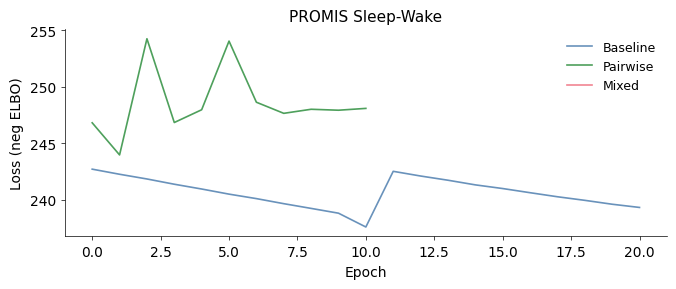

In [14]:
fig = plot_loss_comparison(losses_baseline, losses_imputed, title='PROMIS Sleep-Wake',
                          losses_pairwise=losses_pairwise)
fig.savefig('loss_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [15]:
calibrate_manually(model_pairwise, n_samples=32, seed=103)
calibrate_manually(model_imputed, n_samples=32, seed=102)

## 7. Ignorability Analysis

Compute per-item adaptive thresholds comparing pairwise imputation ELPD
against baseline IRT ELPD. Items whose missing values are **ignorable**
do not benefit from imputation over the baseline's own marginalization.

In [16]:
model_imputed.compute_adaptive_thresholds(
    data_factory, baseline_model=model_baseline, sample_size=32
)

import pandas as pd
ignorability_df = pd.DataFrame([
    {
        'Item': item,
        'w_pairwise': f"{mixed_imputation.get_item_weight(item):.4f}",
        'Threshold': f"{model_imputed._adaptive_thresholds[item]:.4f}",
        'Missing Ignorable': model_imputed._ignorable_items[item],
    }
    for item in item_keys
])
n_ignorable = sum(model_imputed._ignorable_items[k] for k in item_keys)
print(f"Ignorability: {n_ignorable}/{len(item_keys)} items have ignorable missing values\n")
print(ignorability_df.to_string(index=False))

model_imputed.save_to_disk('grm_imputed')

Ignorability: 0/126 items have ignorable missing values

    Item w_pairwise Threshold  Missing Ignorable
  Sleep1     0.5729    0.0010              False
  Sleep2     0.8441    0.0010              False
  Sleep3     0.6237    0.0010              False
  Sleep4     1.0000    0.0010              False
  Sleep5     0.6724    0.0010              False
  Sleep6     1.0000    0.0010              False
  Sleep7     0.8702    0.0010              False
  Sleep8     0.7922    0.0010              False
  Sleep9     0.9404    0.0010              False
 Sleep10     1.0000    0.0010              False
 Sleep11     0.5956    0.0010              False
 Sleep12     0.7180    0.0010              False
 Sleep13     1.0000    0.0010              False
 Sleep14     0.5276    0.0010              False
 Sleep15     0.7153    0.0010              False
 Sleep16     0.9801    0.0010              False
 Sleep17     0.9997    0.0010              False
 Sleep18     0.9920    0.0010              False
 Sleep19    

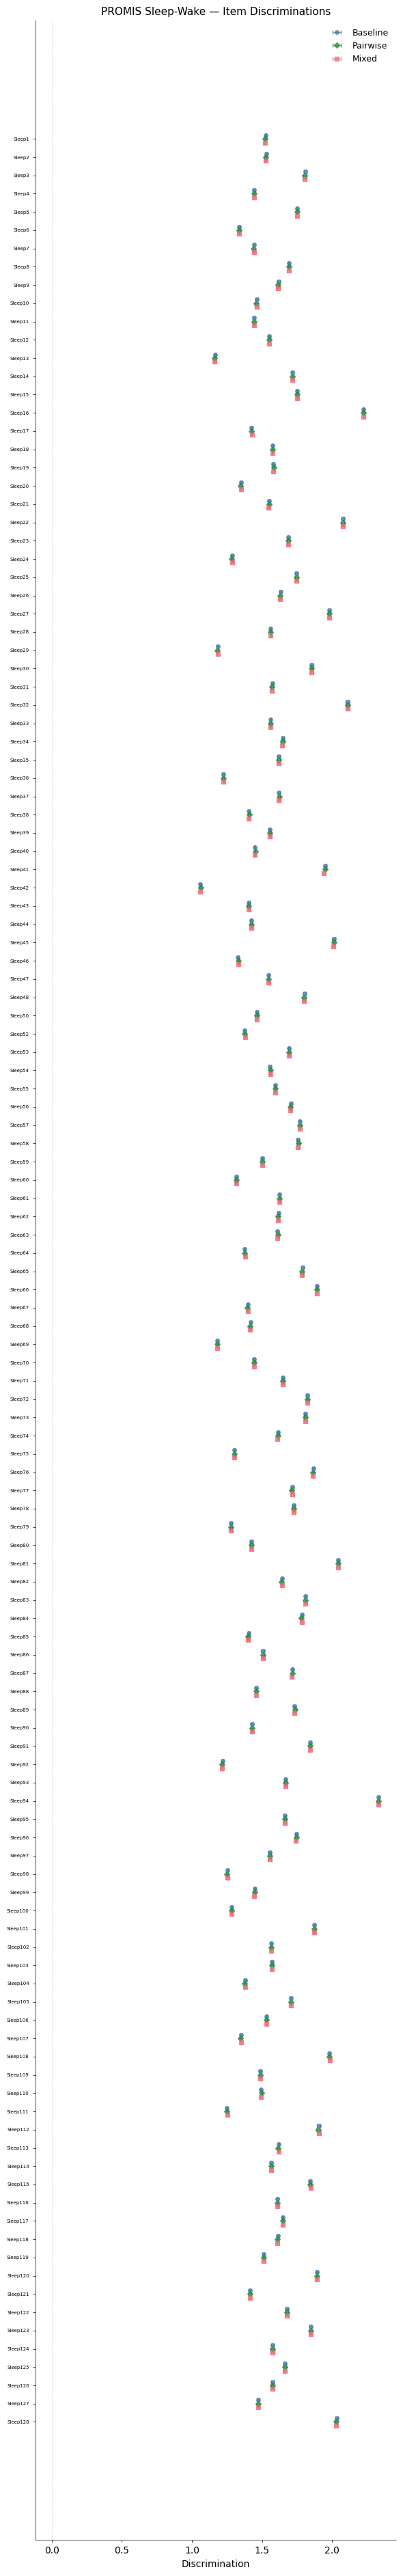

In [17]:
fig = plot_forest_discriminations(item_keys, model_baseline, model_imputed,
                                   title='PROMIS Sleep-Wake — Item Discriminations',
                                   model_pairwise=model_pairwise)
fig.savefig('discriminations.pdf', bbox_inches='tight', dpi=150)
plt.show()

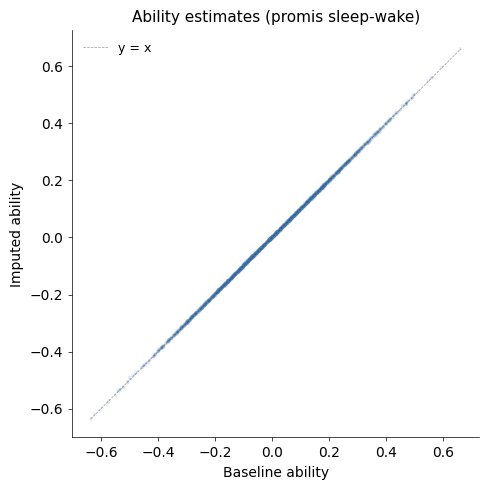

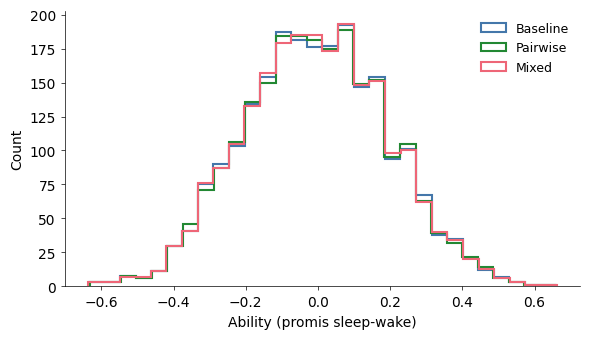

In [18]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_pw = np.array(model_pairwise.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig = plot_ability_scatter(ab_base, ab_imp, label='promis sleep-wake')
fig.savefig('ability_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

fig = plot_ability_distributions(ab_base, ab_imp, label='promis sleep-wake',
                                  abilities_pairwise=ab_pw)
fig.savefig('ability_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

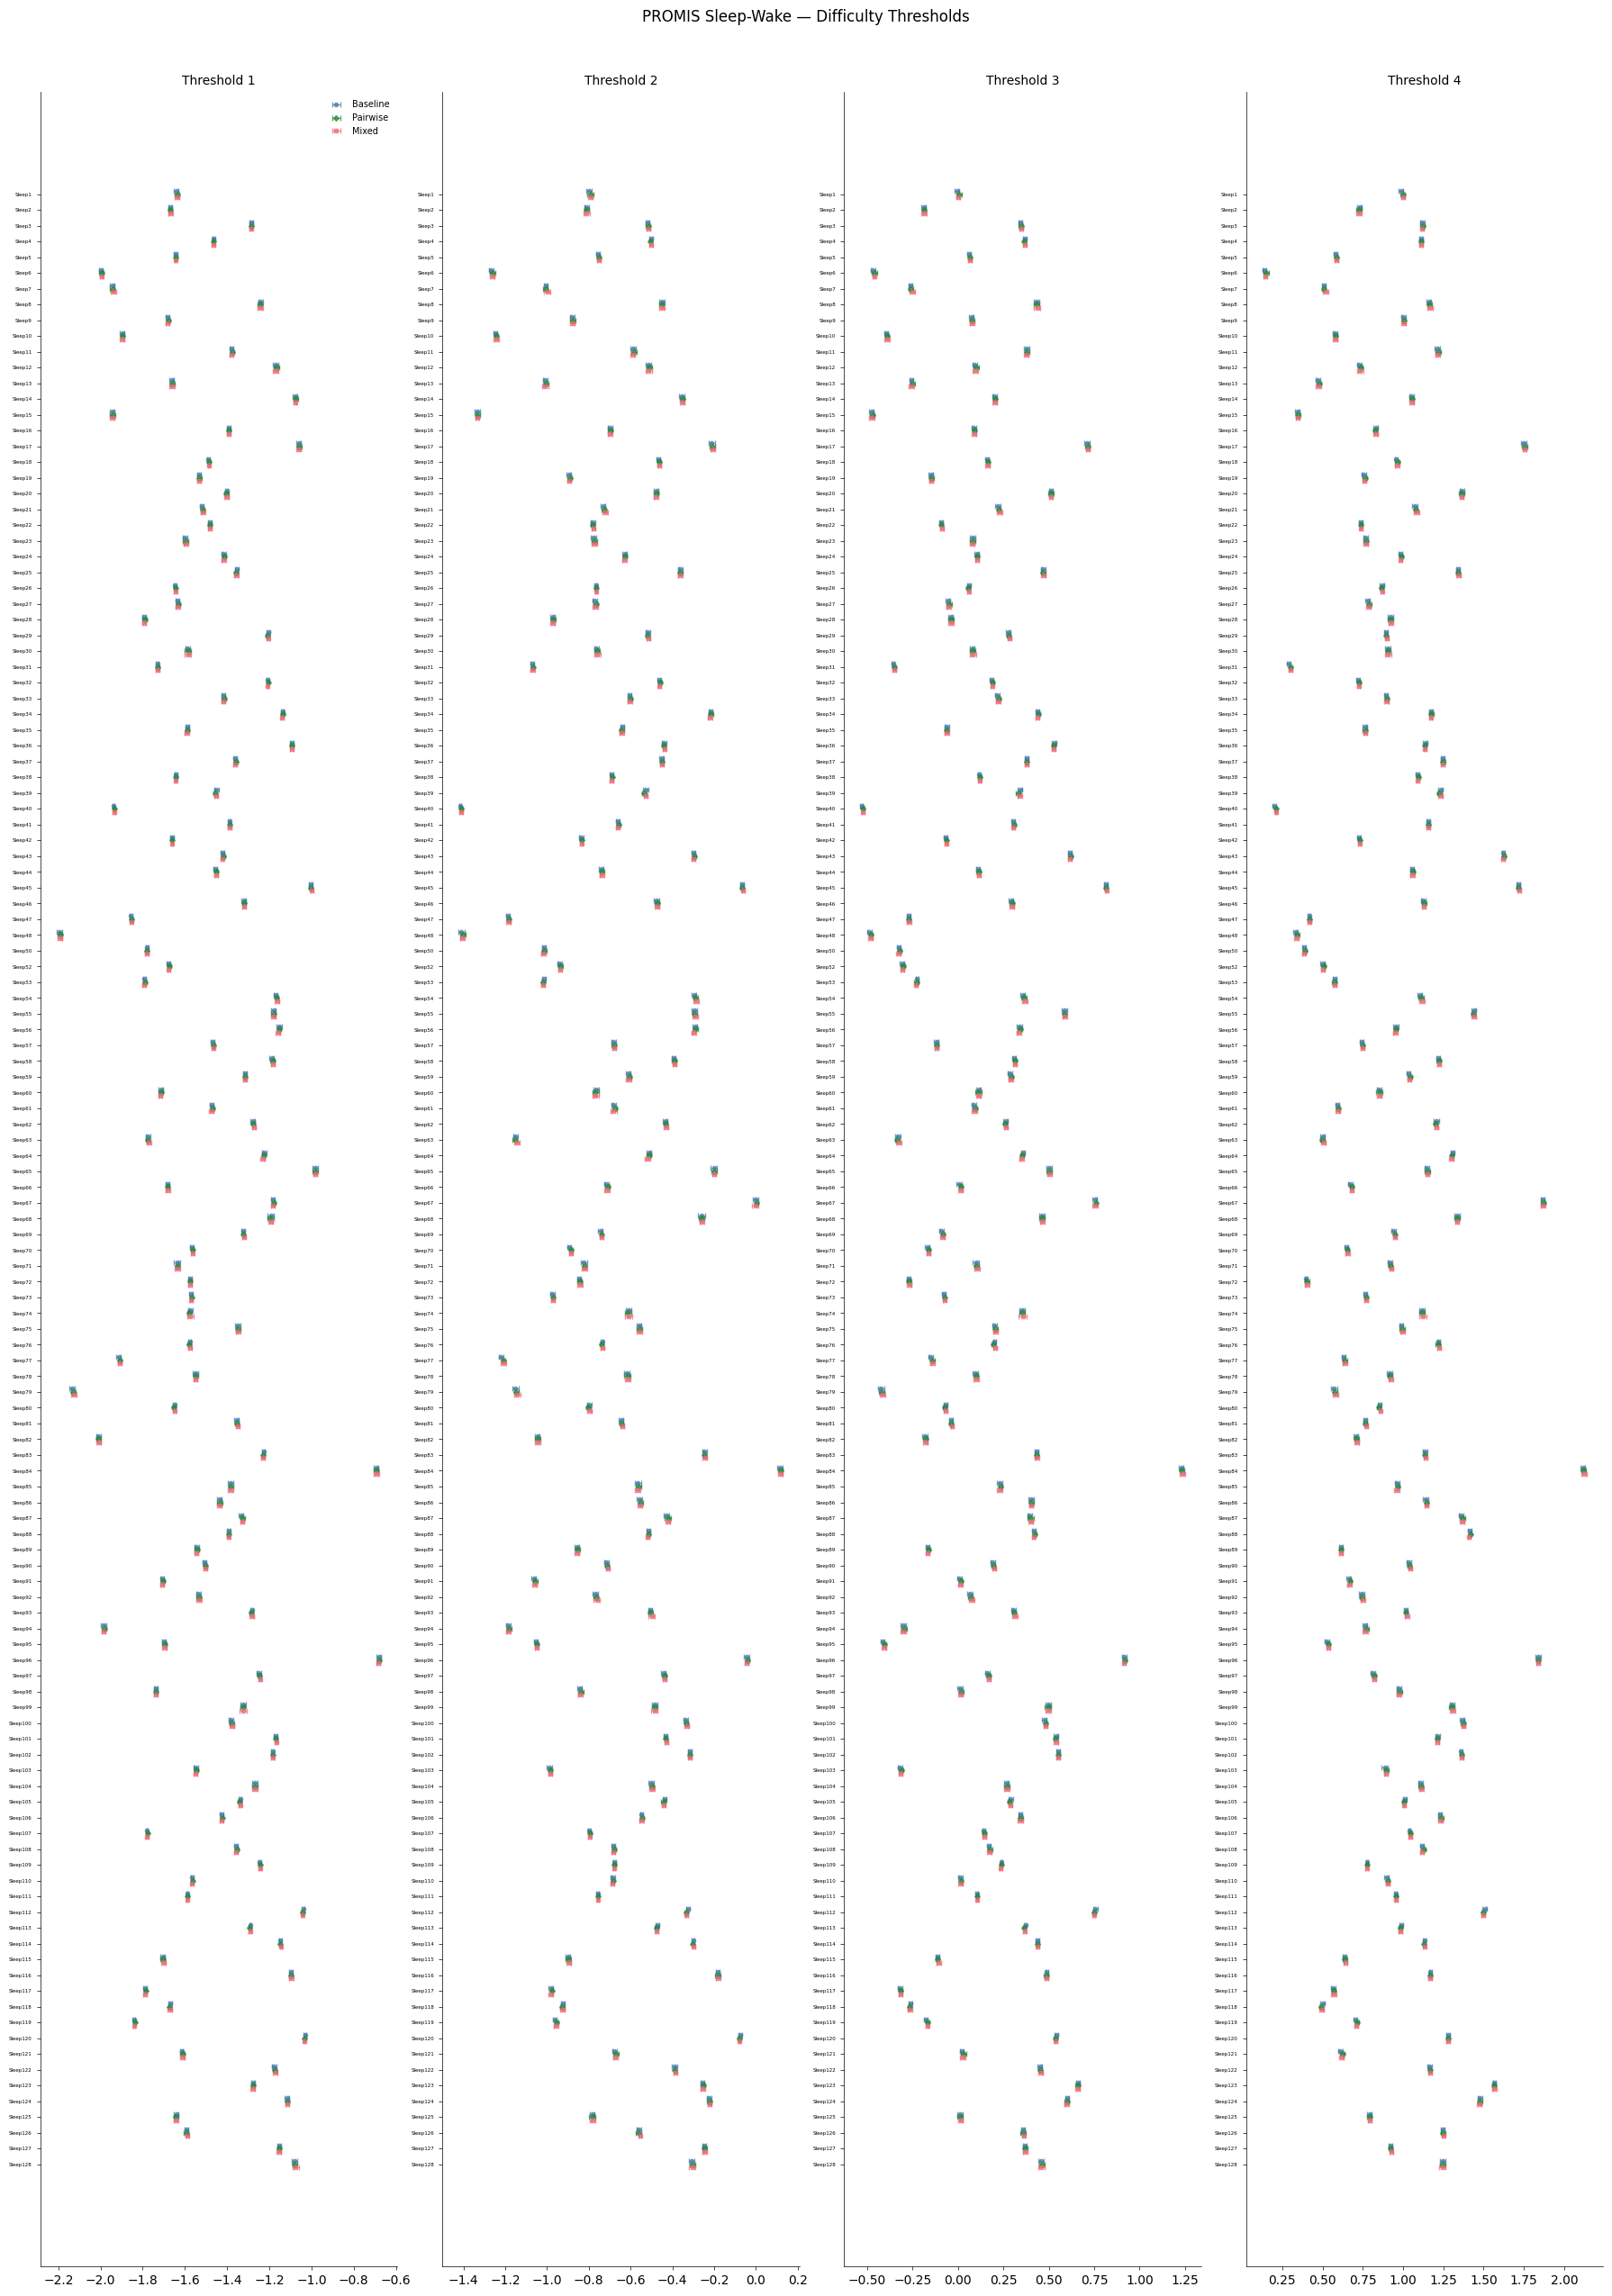

In [19]:
fig = plot_thresholds(item_keys, model_baseline, model_imputed,
                       title='PROMIS Sleep-Wake — Difficulty Thresholds',
                       model_pairwise=model_pairwise)
fig.savefig('thresholds.pdf', bbox_inches='tight', dpi=150)
plt.show()

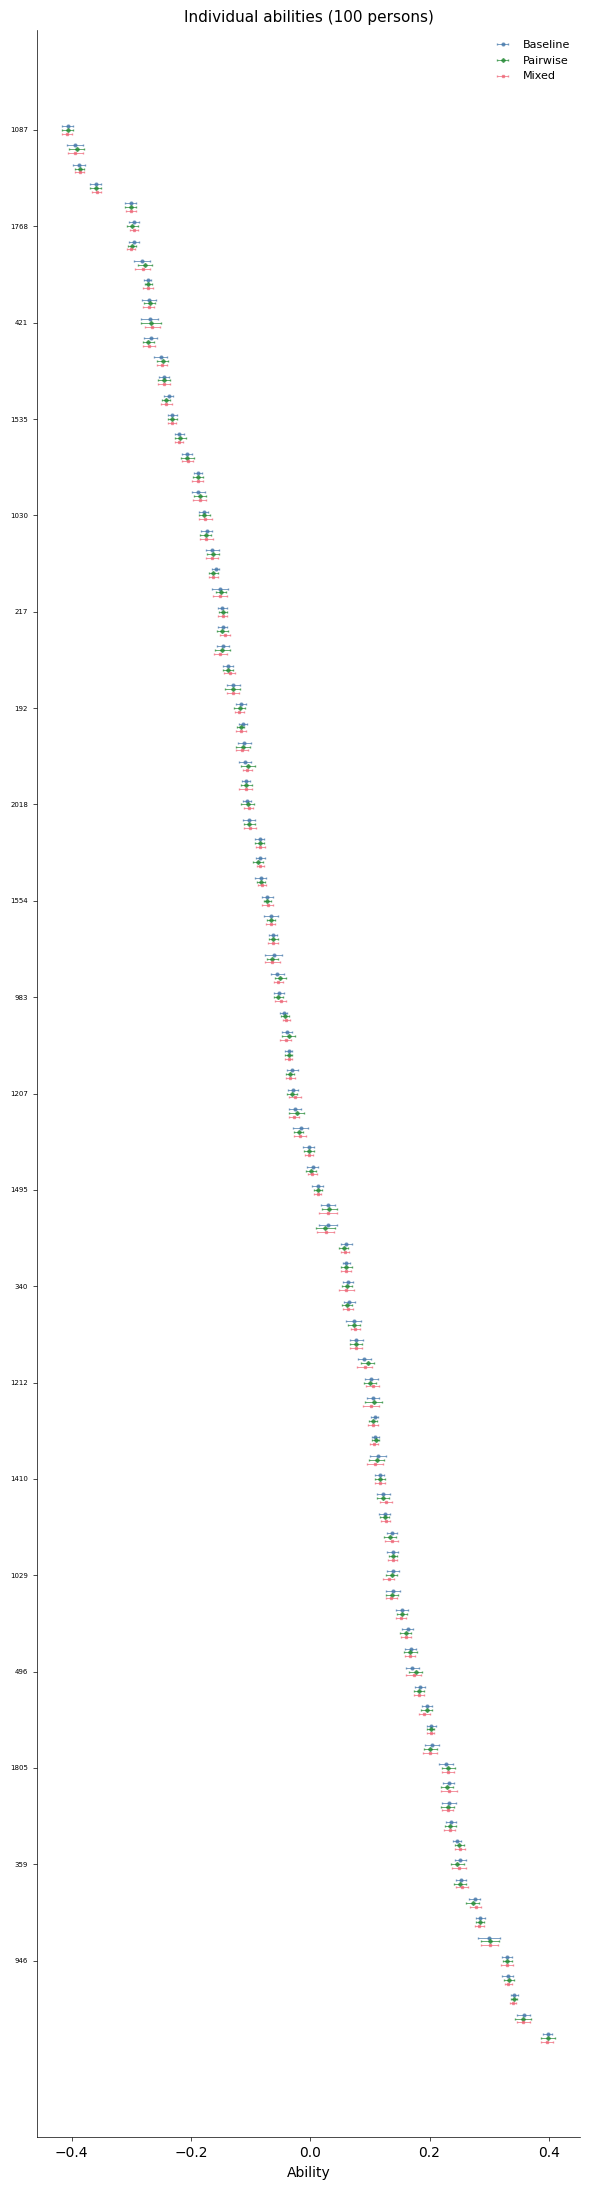

In [20]:
fig = plot_individual_abilities(item_keys, model_baseline, model_imputed,
                                model_pairwise=model_pairwise)
fig.savefig('individual_abilities.pdf', bbox_inches='tight', dpi=150)
plt.show()

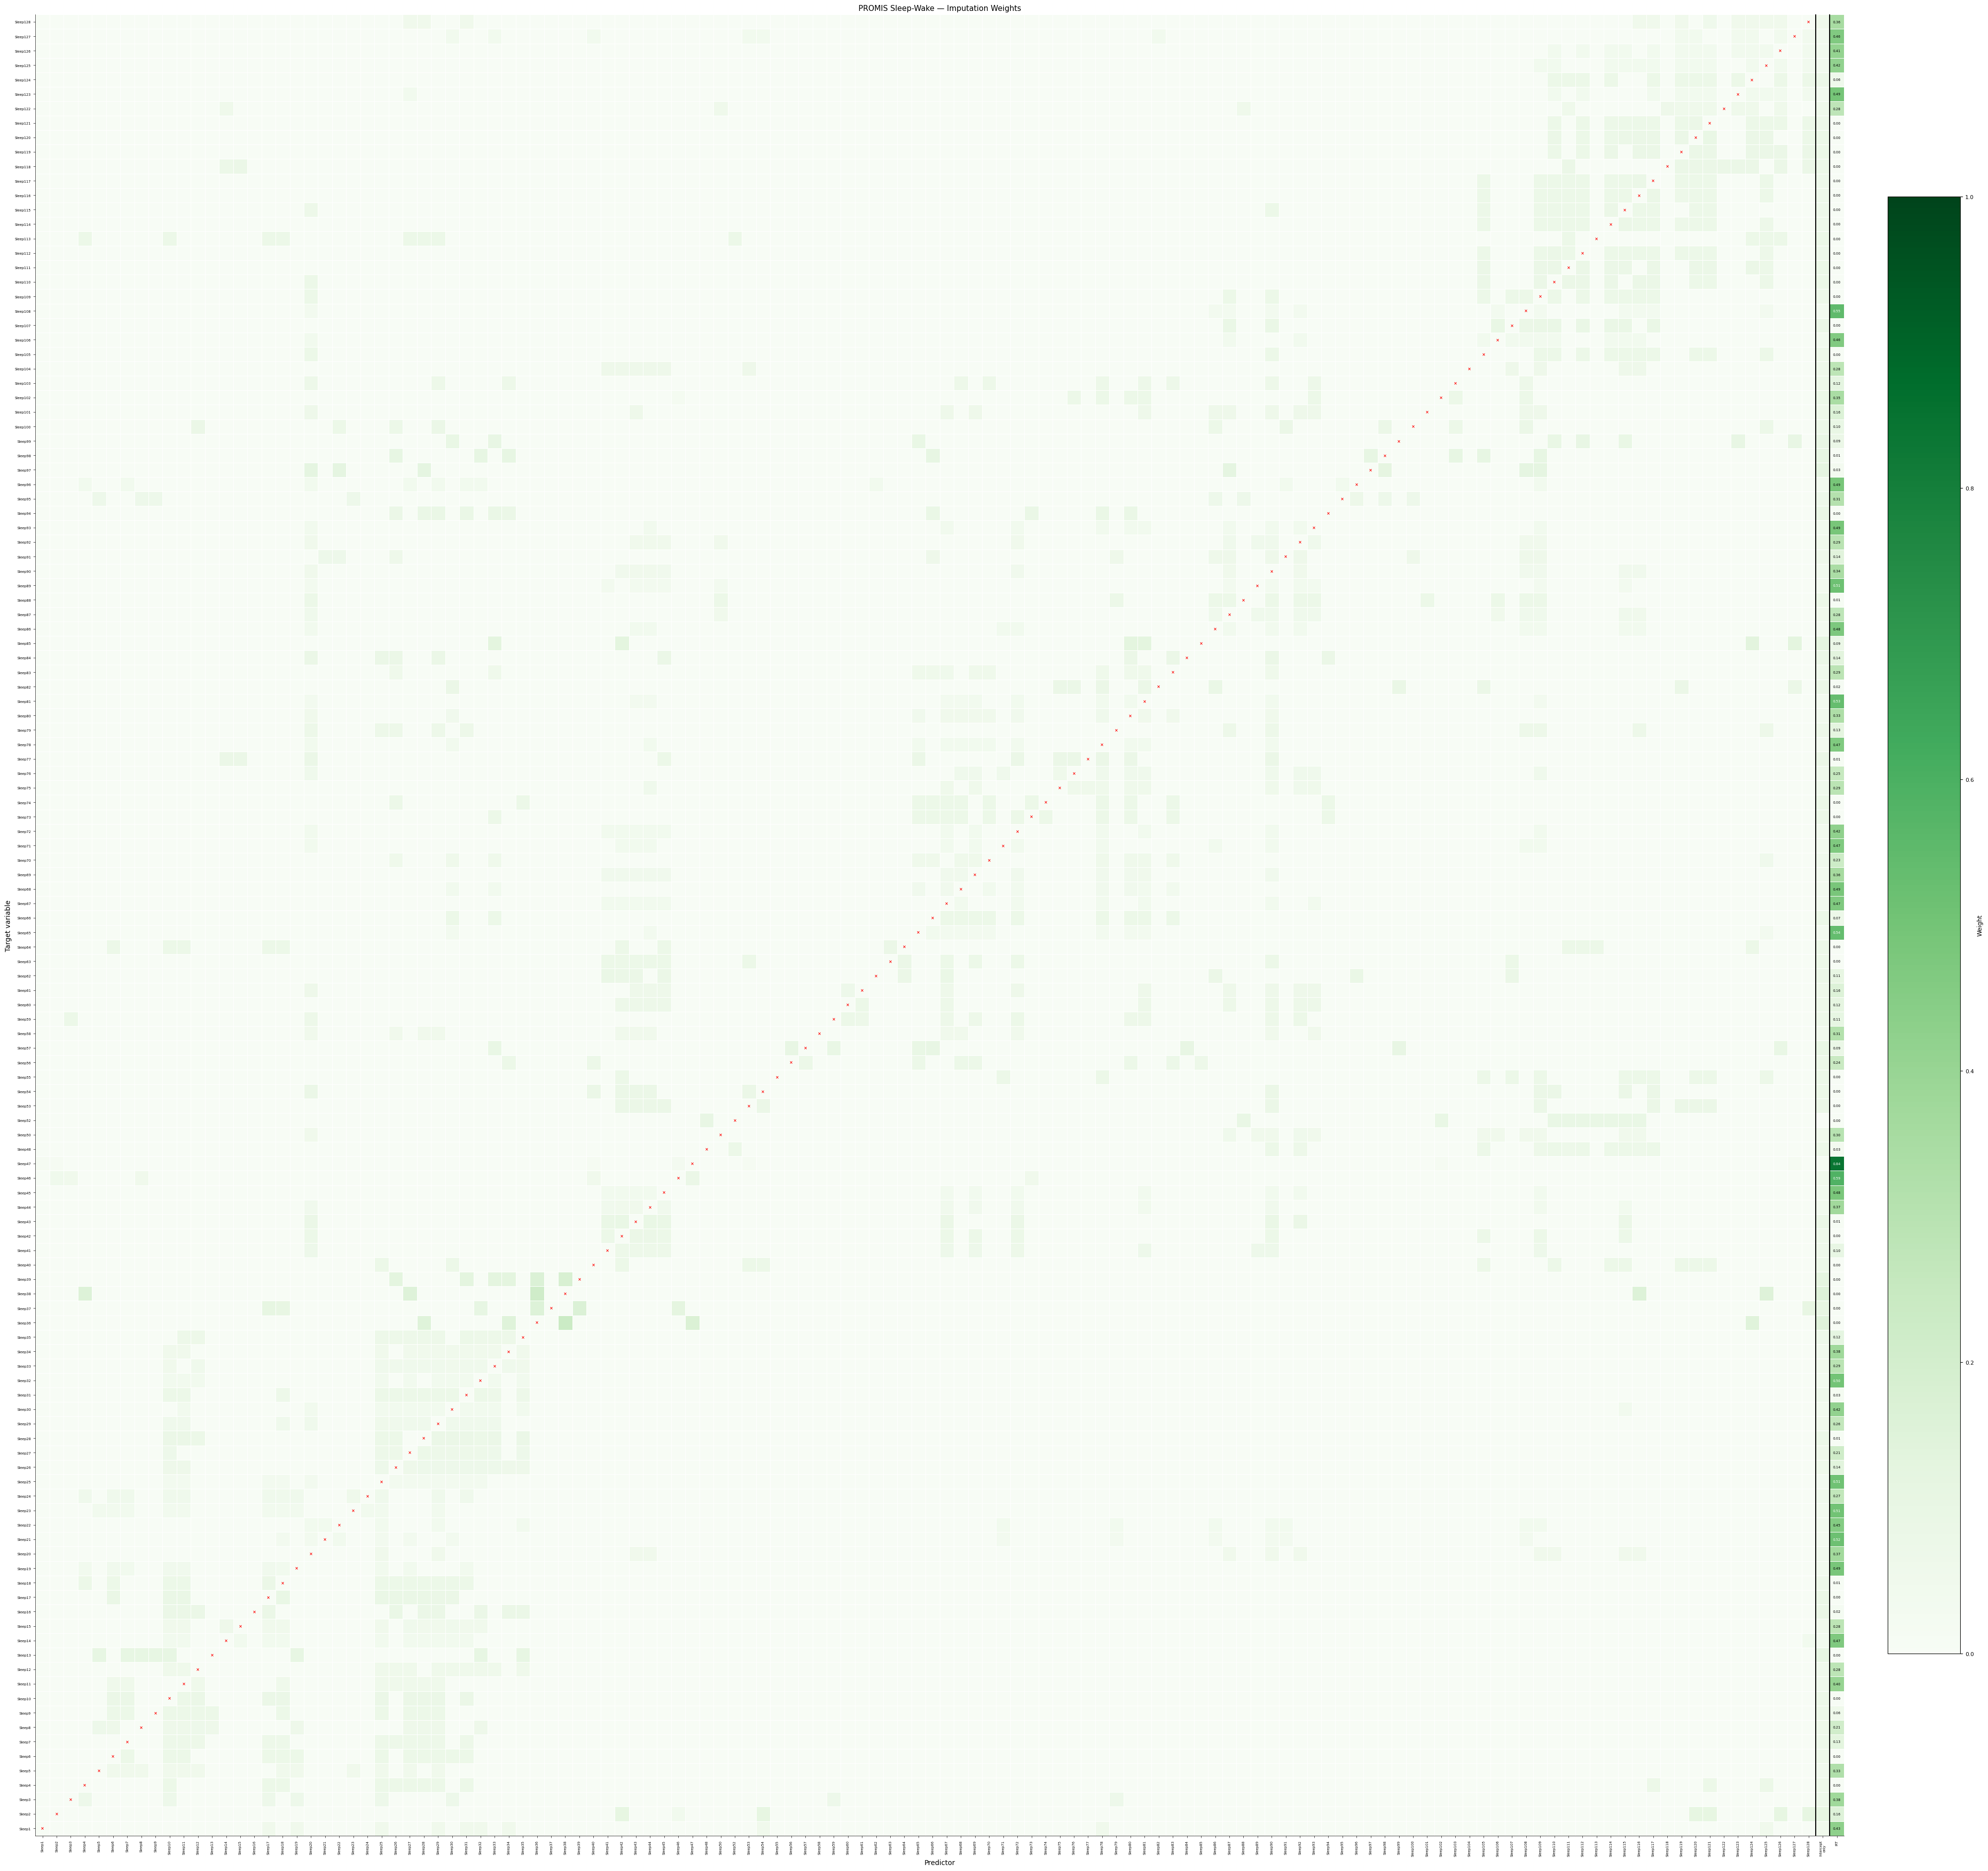

In [21]:
fig = plot_imputation_weights_pcolormesh(pairwise_model, mixed_imputation, item_keys,
                                          title='PROMIS Sleep-Wake — Imputation Weights')
fig.savefig('imputation_weights.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 8. Model Comparison Table

Predictive performance comparison (RMSE and ELPD).

In [22]:
import pandas as pd
from scipy.stats import spearmanr

def compute_predictive_metrics(model, data_factory, item_keys, response_cardinality):
    K = response_cardinality
    all_ll, all_se, all_nr = [], [], []
    all_pred, all_obs = [], []
    for batch_data in data_factory():
        pred = model.predictive_distribution(batch_data, **model.surrogate_sample)
        probs = np.array(pred['rv'].probs_parameter())
        S, N_batch, I, _ = probs.shape
        for n in range(N_batch):
            ll, se, nr = 0.0, 0.0, 0
            for i, key in enumerate(item_keys):
                y = batch_data[key][n]
                if np.isnan(y) or y < 0 or y >= K: continue
                y_int = int(y)
                p_mean = probs[:, n, i, :].mean(0)
                ll += np.log(np.maximum(probs[:, n, i, y_int].mean(), 1e-30))
                expected = np.sum(p_mean * np.arange(K))
                se += (expected - y_int) ** 2
                all_pred.append(expected)
                all_obs.append(y_int)
                nr += 1
            if nr > 0: all_ll.append(ll); all_se.append(se); all_nr.append(nr)
    ll, se, nr = np.array(all_ll), np.array(all_se), np.array(all_nr)
    N, total = len(ll), nr.sum()
    rho, _ = spearmanr(all_obs, all_pred)
    return {
        'RMSE': (np.sqrt(se.sum()/total), np.std(np.sqrt(se/nr))/np.sqrt(N)),
        'ELPD/n': (ll.mean(), np.std(ll)/np.sqrt(N)),
        'ELPD/resp': (ll.sum()/total, np.std(ll/nr)/np.sqrt(N)),
        'Spearman': (rho, 0.0),
    }

m_b = compute_predictive_metrics(model_baseline, data_factory, item_keys, response_cardinality)
m_p = compute_predictive_metrics(model_pairwise, data_factory, item_keys, response_cardinality)
m_m = compute_predictive_metrics(model_imputed, data_factory, item_keys, response_cardinality)

rows = []
for metric in ['RMSE', 'ELPD/n', 'ELPD/resp', 'Spearman']:
    b_val, b_se = m_b[metric]
    p_val, p_se = m_p[metric]
    m_val, m_se = m_m[metric]
    if metric == 'Spearman':
        rows.append({
            'Metric': metric,
            'Baseline': f"{b_val:.4f}",
            'Pairwise': f"{p_val:.4f}",
            'Mixed': f"{m_val:.4f}",
        })
    else:
        rows.append({
            'Metric': metric,
            'Baseline': f"{b_val:.3f} ({b_se:.3f})",
            'Pairwise': f"{p_val:.3f} ({p_se:.3f})",
            'Mixed': f"{m_val:.3f} ({m_se:.3f})",
        })
print("PROMIS Sleep-Wake — Predictive Performance Comparison\n")
print(pd.DataFrame(rows).to_string(index=False))

PROMIS Sleep-Wake — Predictive Performance Comparison

   Metric         Baseline         Pairwise            Mixed
     RMSE    1.754 (0.005)    1.751 (0.005)    1.751 (0.005)
   ELPD/n -238.825 (0.554) -238.466 (0.552) -238.495 (0.552)
ELPD/resp   -1.988 (0.005)   -1.985 (0.004)   -1.985 (0.004)
 Spearman           0.0053           0.0066           0.0066


## Summary

This notebook fitted a single-scale Graded Response Model to
120 PROMIS Sleep-Wake calibration items (Sleep1–Sleep128, excluding
Sleep49 and Sleep51) with 5 response categories (0–4).

The item pool spans both the Sleep Disturbance and Sleep-Related
Impairment PROMIS banks, plus additional calibration candidates.